In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.metrics import classification_report
from sklearn.discriminant_analysis import StandardScaler

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Загрузка данных
# Предполагаем, что есть CSV с колонками: datetime, open, high, low, close, volume
# df = pd.read_csv('dowload_data/CNYRUBF_1Min.txt', parse_dates=['datetime'], index_col='datetime')
def readQuotes(path):
    try:
        quotes = pd.read_csv(path, sep=';')
        quotes['date'] = quotes['date'] + ' ' + quotes['time']
        del quotes['time']
        quotes['date'] = pd.to_datetime(quotes['date'], format='%d.%m.%Y %H:%M:%S', errors='raise', dayfirst=True)
        quotes.index = quotes['date']
        quotes.index.name = 'Date'
        del quotes['date']
        quotes[quotes.columns].astype(float)
        return quotes
    except pd.errors.EmptyDataError:
        print(f"File {path} is empty")
        return pd.DataFrame()
    except pd.errors.ParserError as e:
        print(f"Error parsing file {path}: {e}")

In [4]:
df_base = readQuotes('..\dowload_data\CNYRUBF_5Min.txt')
df_history = readQuotes('..\dowload_data\CNYRUBF_5Min_history.txt')

df_base = pd.concat([df_history, df_base])

In [198]:
# 2. Параметры стратегии
N = 36    # число баров во входном окне (6*5 мин = 30 мин признаков)
M = 6     # число баров вперед для оценки результата (т.е. через 30 мин)

In [214]:
# Процент изменения цены за день
df_base["Pct_Change"] = df_base["close"].pct_change(periods=M) * 100

# Определение классов
threshhold = 0.2
conditions = [
    (df_base["Pct_Change"] > threshhold),   # Сильный рост
    (df_base["Pct_Change"] > 0) & (df_base["Pct_Change"] <= threshhold),  # Слабый рост
    (df_base["Pct_Change"] >= -threshhold) & (df_base["Pct_Change"] < 0), # Слабое падение
    (df_base["Pct_Change"] < -threshhold)   # Сильное падение
]

labels = [3, 2, 1, 0]  # 3=Strong Up, 2=Weak Up, 1=Weak Down, 0=Strong Down
df_base["target"] = np.select(conditions, labels, default=np.nan)

# Удаление NaN (первая строка из-за pct_change)
df_base = df_base.dropna()

df_base['target'].value_counts()

target
2.0    18150
1.0    17660
0.0     4443
3.0     4266
Name: count, dtype: int64

In [215]:
df = df_base.loc[:'2025-04-29 10:00:00',:].copy()
for i in range(N):
    df[f'o_{i}'] = df['open'].shift(i)
    df[f'h_{i}'] = df['high'].shift(i)
    df[f'l_{i}'] = df['low'].shift(i)
    df[f'c_{i}'] = df['close'].shift(i)
    df[f'v_{i}'] = df['volume'].shift(i)

del df['Pct_Change']

feature_cols = [col for col in df.columns if '_' in col]  # все o_i, h_i, ..., v_i
X = df[feature_cols].dropna()
y = df.loc[X.index, 'target']

In [216]:
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [173]:
X_train.shape

(37564, 180)

In [217]:
y.value_counts()

target
2.0    18097
1.0    17600
0.0     4421
3.0     4251
Name: count, dtype: int64

In [218]:
# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание на тесте
y_pred = model.predict(X_test)

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

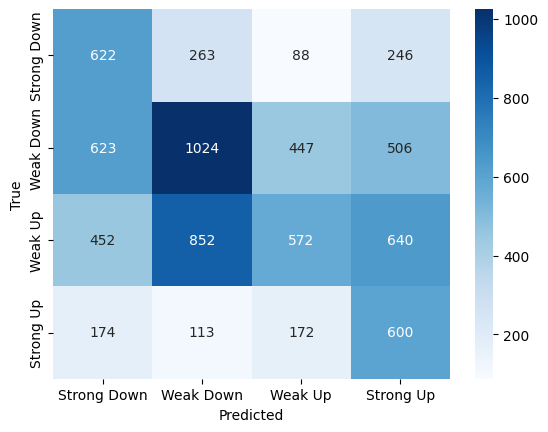

              precision    recall  f1-score   support

 Strong Down       0.33      0.51      0.40      1219
   Weak Down       0.45      0.39      0.42      2600
     Weak Up       0.45      0.23      0.30      2516
   Strong Up       0.30      0.57      0.39      1059

    accuracy                           0.38      7394
   macro avg       0.38      0.42      0.38      7394
weighted avg       0.41      0.38      0.37      7394



In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Strong Down", "Weak Down", "Weak Up", "Strong Up"],
            yticklabels=["Strong Down", "Weak Down", "Weak Up", "Strong Up"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Отчет классификации
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Strong Down", "Weak Down", "Weak Up", "Strong Up"]
    )
)

In [166]:
# 9. Функция предсказания вероятностей для новых данных
def predict_signal(recent_bars: pd.DataFrame, model) -> pd.Series:
    """
    recent_bars: DataFrame из последних N баров с колонками ['open','high','low','close','volume'].
    Должен быть упорядочен по времени, индекс не обязателен.
    """
    # Проверка размера
    assert len(recent_bars) >= N, f"Нужно минимум {N} баров, передано {len(recent_bars)}"
    # Берем последние N строк
    window = recent_bars.iloc[-N:].copy()
    feats = {}
    for i in range(N):
        row = window.iloc[-1-i]
        feats.update({
            f'o_{i}': row['open'],
            f'h_{i}': row['high'],
            f'l_{i}': row['low'],
            f'c_{i}': row['close'],
            f'v_{i}': row['volume'],
        })
    X_new = pd.DataFrame([feats])
    # Получаем вероятности
    proba = model.predict_proba(X_new)[0]
    # proba[model.classes_ == 1] — вероятность profitable long
    # proba[model.classes_ == -1] — вероятность profitable short
    return pd.Series({
        'Strong Down': proba[list(model.classes_).index(0)],
        'Weak Down': proba[list(model.classes_).index(1)],
        'Weak Up': proba[list(model.classes_).index(2)],
        'Strong Up': proba[list(model.classes_).index(3)]
    })

# Пример использования:
# recent = df[['open','high','low','close','volume']].iloc[-10:]  # возьмём 10 последних баров
# print(predict_signal(recent))

In [167]:
list(model.classes_)

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

In [222]:
predict_signal(df_base.loc[:'2025-04-29 14:15:00',:], model)

Strong Down    0.28
Weak Down      0.09
Weak Up        0.17
Strong Up      0.46
dtype: float64